# Dissertation: Autonomous Agent for Alpha Discovery in Indian Equity Markets

**Author:** Abhinav Gazta  
**Course:** S1-25_AIMLCZG628T (Dissertation)  
**Topic:** Financial Machine Learning & Deep Reinforcement Learning (DRL)

---

## 1. Methodology & Reward Formulation

This notebook implements a **Single-Agent DRL** framework trained on daily OHLCV data. The reward function is explicitly designed to model the frictions of the Indian Equity Market (NSE/BSE), including **Securities Transaction Tax (STT)** and **Liquidity Slippage**.

### 1.1 Mathematical Formulation

**Step 1: Realized Asset Log-Return** 
To ensure numerical stability and symmetry[cite: 450], returns are calculated using Open prices:
$$
r_{i,t+1} = \ln \left( \frac{Open_{i,t+1}}{Open_{i,t}} \right)
$$

**Step 2: Gross Portfolio Return** 
For portfolio weights $w_t$:
$$
Gross\_Return_t = \sum ( w_{i,t} \cdot r_{i,t+1} )
$$

**Step 3: Transaction Costs (Linear & Quadratic)** 
We model brokerage/STT as linear and market impact (slippage) as quadratic relative to liquidity (ADV)[cite: 461, 468]:
$$
TC_{linear,t} = \alpha \cdot \sum | w_{i,t} - w_{i,t-1} |
$$
$$
TC_{slippage,t} = \beta \cdot \left( \frac{\sum |w_{i,t} - w_{i,t-1}| \cdot PortfolioValue_t}{ADV_t} \right)^2
$$

**Step 4: Reward Function (Risk-Adjusted)** 
The final reward penalizes downside variance without punishing upside volatility (Sortino-style logic)[cite: 483]:
$$
Net\_Return_t = Gross\_Return_t - TC_{linear,t} - TC_{slippage,t}
$$
$$
R_t = Net\_Return_t - \gamma \cdot \min(0, Net\_Return_t)^2
$$

### 1.2 Hyperparameter Ranges (Bayesian Optimization)
The following ranges are used for tuning[cite: 502, 503, 504]:
* **$\alpha$ (Turnover Penalty):** $0.001 - 0.01$
* **$\beta$ (Slippage Penalty):** $0.01 - 0.1$
* **$\gamma$ (Downside Risk):** $5.0 - 20.0$

In [1]:
import gymnasium as gym
from gymnasium import spaces
import pandas as pd
import numpy as np
import yfinance as yf
import torch
import torch.nn as nn
import torch.optim as optim
from stable_baselines3 import PPO
from stable_baselines3.common.torch_layers import BaseFeaturesExtractor
import ta
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import optuna
import scipy.stats as stats
import warnings

# Suppress warnings
warnings.filterwarnings("ignore")

# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


/opt/homebrew/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ==========================================
# 2. METRICS LIBRARY
# ==========================================
class FinancialMetrics:
    @staticmethod
    def get_max_drawdown(prices):
        prices = np.array(prices)
        if len(prices) < 2: return 0.0
        peaks = np.maximum.accumulate(prices)
        with np.errstate(divide='ignore', invalid='ignore'):
            drawdowns = (prices - peaks) / (peaks + 1e-9)
        return np.min(np.nan_to_num(drawdowns))

    @staticmethod
    def get_sharpe_ratio(returns, risk_free_rate=0.06):
        returns = np.nan_to_num(returns)
        if len(returns) < 2: return 0.0
        excess_ret = returns - (risk_free_rate / 252)
        std_dev = np.std(excess_ret)
        if std_dev < 1e-9: return 0.0
        return (np.mean(excess_ret) / std_dev) * np.sqrt(252)

    @staticmethod
    def get_sortino_ratio(returns, risk_free_rate=0.06):
        returns = np.nan_to_num(returns)
        excess_ret = returns - (risk_free_rate / 252)
        downside_returns = excess_ret[excess_ret < 0]
        downside_std = np.std(downside_returns)
        if downside_std < 1e-9: return 0.0
        return (np.mean(excess_ret) / downside_std) * np.sqrt(252)

    @staticmethod
    def probabilistic_sharpe_ratio(returns, benchmark_sharpe=0):
        returns = np.nan_to_num(returns)
        if len(returns) < 2: return 0.0
        sr = FinancialMetrics.get_sharpe_ratio(returns)
        skew = stats.skew(returns)
        kurtosis = stats.kurtosis(returns)
        n = len(returns)
        denom = (n - 1) if n > 1 else 1
        sr_std = np.sqrt((1 + (0.5 * skew * sr) + ((kurtosis - 3) / 4) * sr**2) / denom)
        if sr_std < 1e-9: return 0.0
        return stats.norm.cdf((sr - benchmark_sharpe) / sr_std)

In [3]:
# ==========================================
# 3. DATA ENGINEERING (OHLCV)
# ==========================================
def fetch_and_process_data(tickers, start_date="2015-01-01", end_date="2025-01-01"):
    print(f"Fetching data for {len(tickers)} assets...")
    data = yf.download(tickers, start=start_date, end=end_date, group_by='ticker', auto_adjust=True)
    processed_frames = []
    
    for ticker in tickers:
        # Handle yfinance multi-index or single-index
        if len(tickers) == 1:
            df = data.copy()
        else:
            try:
                df = data[ticker].copy()
            except KeyError:
                continue
                
        if df.empty: continue
        
        # --- Technical Indicators ---
        # Ensure we use 1D arrays for TA-Lib to avoid shape errors
        close = df['Close'].squeeze()
        high = df['High'].squeeze()
        low = df['Low'].squeeze()
        volume = df['Volume'].squeeze()
        
        # 1. Log Returns (Open-to-Open for Stationarity)
        # r_{t} = ln(Open_t / Open_{t-1})
        df['log_ret'] = np.log(df['Open'] / (df['Open'].shift(1) + 1e-8))
        
        # 2. Momentum & Trend
        df['rsi'] = ta.momentum.RSIIndicator(close, window=14).rsi() / 100.0
        macd = ta.trend.MACD(close)
        df['macd'] = macd.macd_diff()
        
        # 3. Volatility
        bb = ta.volatility.BollingerBands(close)
        df['bb_width'] = (bb.bollinger_hband() - bb.bollinger_lband()) / (close + 1e-8)
        df['atr'] = ta.volatility.AverageTrueRange(high, low, close).average_true_range()
        
        # 4. Liquidity / ADV (Average Daily Value)
        # ADV = Volume * Open (Approximation of traded value)
        daily_value = volume * df['Open']
        df['adv_20'] = daily_value.rolling(window=20).mean()
        df['vol_ratio'] = daily_value / (df['adv_20'] + 1e-8)
        
        df.dropna(inplace=True)
        
        # 5. Normalization (Rolling Z-Score)
        cols_to_norm = ['log_ret', 'rsi', 'macd', 'bb_width', 'vol_ratio']
        for col in cols_to_norm:
            rolling_mean = df[col].rolling(60).mean()
            rolling_std = df[col].rolling(60).std()
            df[col] = (df[col] - rolling_mean) / (rolling_std + 1e-8)
            
        df['ticker'] = ticker
        processed_frames.append(df.dropna())

    if not processed_frames:
        raise ValueError("No data downloaded.")
        
    combined = pd.concat(processed_frames)
    # Pivot keeping all required columns
    pivot_df = combined.pivot_table(index='Date', columns='ticker', 
                                    values=['Open', 'log_ret', 'rsi', 'macd', 'bb_width', 'vol_ratio', 'atr', 'adv_20'])
    
    pivot_df.replace([np.inf, -np.inf], np.nan, inplace=True)
    pivot_df.dropna(inplace=True)
    
    return pivot_df

In [4]:
# ==========================================
# 4. COST-AWARE MARKET SIMULATOR
# ==========================================
class IndianEquityEnv(gym.Env):
    def __init__(self, df, reward_params=None, lookback_window=30, initial_balance=1_000_000):
        super(IndianEquityEnv, self).__init__()
        self.df = df
        # Extract tickers from the columns MultiIndex
        self.tickers = df['Open'].columns.tolist()
        self.n_assets = len(self.tickers)
        self.lookback = lookback_window
        self.initial_balance = initial_balance
        
        # Hyperparameters (Defaults match the Safe Ranges)
        self.reward_params = reward_params if reward_params else {
            'alpha': 0.005,  # Turnover (Linear)
            'beta': 0.05,    # Slippage (Quadratic)
            'gamma': 10.0    # Downside Risk
        }
        
        self.action_space = spaces.Box(low=-1, high=1, shape=(self.n_assets + 1,), dtype=np.float32)
        self.n_features = 5 
        self.obs_shape = (lookback_window, self.n_assets * self.n_features)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=self.obs_shape, dtype=np.float32)
        
    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        self.current_step = self.lookback
        self.weights = np.zeros(self.n_assets + 1)
        self.weights[0] = 1.0 # 100% Cash initially
        self.portfolio_value = self.initial_balance
        return self._get_obs(), {}

    def _get_obs(self):
        idx = self.current_step
        obs_data = []
        # Feature Groups
        for feat in ['log_ret', 'rsi', 'macd', 'bb_width', 'vol_ratio']:
            obs_data.append(self.df[feat].iloc[idx-self.lookback:idx].values)
        return np.concatenate(obs_data, axis=1).astype(np.float32)

    def step(self, action):
        # 1. Action -> Weights (Softmax)
        exp_action = np.exp(action)
        weights = exp_action / np.sum(exp_action)
        
        # 2. Get Data for t and t+1
        # Note: Decision at Close t, Executed at Open t+1.
        # We model return as ln(Open_{t+1} / Open_t).
        # Ideally, this return is realized over the step.
        
        # Current Open (t) and Next Open (t+1)
        # We check boundaries
        if self.current_step >= len(self.df) - 1:
            return self._get_obs(), 0, True, False, {}

        open_t = self.df['Open'].iloc[self.current_step].values
        open_t1 = self.df['Open'].iloc[self.current_step + 1].values
        
        # 3. Step 1: Realized Asset Log-Return [cite: 450]
        # r_{i,t+1} = ln(Open_{i,t+1} / Open_{i,t})
        asset_log_returns = np.log(open_t1 / (open_t + 1e-8))
        
        # 4. Step 2: Gross Portfolio Return [cite: 457]
        # Gross = Sum(w_{i,t} * r_{i,t+1})
        # weights[1:] corresponds to assets, weights[0] is cash (r=0)
        gross_return = np.dot(weights[1:], asset_log_returns)
        
        # 5. Step 3: Transaction Costs [cite: 461, 468]
        # Turnover = Sum |w_t - w_{t-1}|
        delta_weights = np.abs(weights - self.weights)
        turnover = np.sum(delta_weights)
        
        # Linear Cost (Brokerage + STT)
        cost_linear = self.reward_params['alpha'] * turnover
        
        # Quadratic Slippage (Market Impact)
        # Trade Value approx = Delta_W * PortfolioValue
        trade_values = delta_weights[1:] * self.portfolio_value
        advs = self.df['adv_20'].iloc[self.current_step].values
        
        # TC_slippage = Beta * (Trade_Value / ADV)^2
        # We sum this impact across all assets
        cost_slippage = self.reward_params['beta'] * np.sum((trade_values / (advs + 1e-8))**2)
        
        # Normalize slippage as a percentage return deduction
        cost_slippage_pct = cost_slippage / self.portfolio_value
        
        # 6. Step 4: Net Return [cite: 479]
        net_return = gross_return - cost_linear - cost_slippage_pct
        
        # 7. Step 5: Downside Risk Penalty [cite: 483]
        # Gamma * min(0, Net_Return)^2
        downside_penalty = self.reward_params['gamma'] * (min(0, net_return)**2)
        
        # Final Reward [cite: 488]
        reward = net_return - downside_penalty
        
        # Update State
        self.portfolio_value *= (1 + net_return)
        self.weights = weights
        self.current_step += 1
        
        terminated = self.current_step >= len(self.df) - 1
        
        info = {
            'portfolio_value': self.portfolio_value,
            'net_return': net_return,
            'turnover': turnover,
            'cost_linear': cost_linear,
            'cost_slippage': cost_slippage_pct
        }
        
        return self._get_obs(), reward, terminated, False, info

In [5]:
# ==========================================
# 5. TRANSFORMER MODEL
# ==========================================
class ExplainableTransformer(BaseFeaturesExtractor):
    def __init__(self, observation_space, features_dim=128):
        super().__init__(observation_space, features_dim)
        self.seq_len = observation_space.shape[0]
        self.input_dim = observation_space.shape[1]
        self.d_model = 128
        self.linear_in = nn.Linear(self.input_dim, self.d_model)
        self.mha = nn.MultiheadAttention(embed_dim=self.d_model, num_heads=4, batch_first=True)
        self.norm1 = nn.LayerNorm(self.d_model)
        self.linear_out = nn.Linear(self.seq_len * self.d_model, features_dim)
        self.act = nn.Tanh()

    def forward(self, observations):
        x = self.linear_in(observations)
        attn_output, _ = self.mha(x, x, x, need_weights=False)
        x = self.norm1(x + attn_output)
        x = x.flatten(start_dim=1)
        return self.act(self.linear_out(x))

In [6]:
# ==========================================
# 6. BAYESIAN OPTIMIZATION (OPTUNA)
# ==========================================
def objective(trial, train_df, test_df):
    # Hyperparameter Ranges [cite: 502-504]
    alpha = trial.suggest_float("alpha", 0.001, 0.01) # Turnover
    beta = trial.suggest_float("beta", 0.01, 0.1)     # Slippage
    gamma = trial.suggest_float("gamma", 5.0, 20.0)   # Downside Risk
    
    learning_rate = trial.suggest_float("lr", 1e-5, 1e-3, log=True)
    ent_coef = trial.suggest_float("ent_coef", 0.001, 0.1, log=True)
    
    reward_params = {'alpha': alpha, 'beta': beta, 'gamma': gamma}
    
    env = IndianEquityEnv(train_df, reward_params=reward_params)
    
    model = PPO("MlpPolicy", env, 
                policy_kwargs=dict(features_extractor_class=ExplainableTransformer, 
                                   features_extractor_kwargs=dict(features_dim=128)),
                learning_rate=learning_rate, ent_coef=ent_coef, verbose=0)
    
    model.learn(total_timesteps=2000)
    
    # Evaluation
    eval_env = IndianEquityEnv(test_df, reward_params=reward_params)
    obs, _ = eval_env.reset()
    done = False
    total_reward = 0
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, _, _ = eval_env.step(action)
        total_reward += reward
        done = terminated
        
    return total_reward

Fetching data for 4 assets...


[*********************100%***********************]  4 of 4 completed
[I 2026-02-10 22:49:51,176] A new study created in memory with name: no-name-71104b90-4240-4f96-8c2c-343ad073373e


Data Loaded: (2375, 32)
--- Running Optuna Optimization ---


[I 2026-02-10 22:49:55,749] Trial 0 finished with value: -0.3940258202208243 and parameters: {'alpha': 0.001157928291722708, 'beta': 0.07209653431669866, 'gamma': 19.26405882103419, 'lr': 0.0003526473049446021, 'ent_coef': 0.014452245166041666}. Best is trial 0 with value: -0.3940258202208243.
[I 2026-02-10 22:49:59,725] Trial 1 finished with value: -0.32920032336672855 and parameters: {'alpha': 0.007967521845195518, 'beta': 0.06909086173351317, 'gamma': 16.532925475170053, 'lr': 2.445865706077724e-05, 'ent_coef': 0.034320103402363966}. Best is trial 1 with value: -0.32920032336672855.
[I 2026-02-10 22:50:03,733] Trial 2 finished with value: -0.20528354754212016 and parameters: {'alpha': 0.00991916409111819, 'beta': 0.056623174364834994, 'gamma': 11.056455369676234, 'lr': 1.866873947076289e-05, 'ent_coef': 0.02500826868349373}. Best is trial 2 with value: -0.20528354754212016.


Best Params: {'alpha': 0.00991916409111819, 'beta': 0.056623174364834994, 'gamma': 11.056455369676234, 'lr': 1.866873947076289e-05, 'ent_coef': 0.02500826868349373}
--- Final Training ---


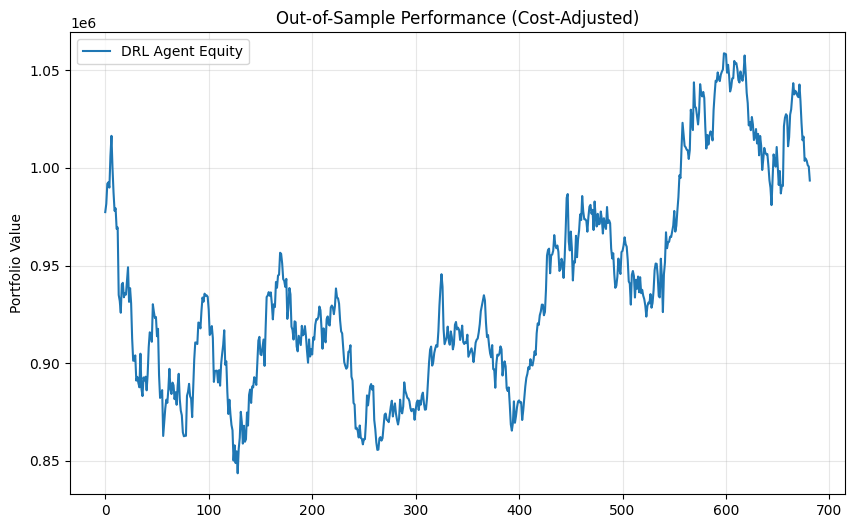

In [7]:
# ==========================================
# 7. MAIN EXECUTION & VISUALIZATION (ROBUST)
# ==========================================
def run_experiment():
    TICKERS = ['RELIANCE.NS', 'INFY.NS', 'HDFCBANK.NS', 'TCS.NS']
    try:
        df_gym = fetch_and_process_data(TICKERS)
        print(f"Data Loaded: {df_gym.shape}")
    except Exception as e:
        print(f"Data Error: {e}"); return

    # Split for tuning
    split_idx = int(len(df_gym) * 0.7)
    train_df = df_gym.iloc[:split_idx]
    test_df = df_gym.iloc[split_idx:]
    
    print("--- Running Optuna Optimization ---")
    study = optuna.create_study(direction="maximize")
    study.optimize(lambda trial: objective(trial, train_df, test_df), n_trials=3)
    best_params = study.best_params
    print("Best Params:", best_params)
    
    # Final Train
    final_reward_params = {
        'alpha': best_params['alpha'],
        'beta': best_params['beta'],
        'gamma': best_params['gamma']
    }
    
    print("--- Final Training ---")
    env_train = IndianEquityEnv(train_df, reward_params=final_reward_params)
    model = PPO("MlpPolicy", env_train, 
                policy_kwargs=dict(features_extractor_class=ExplainableTransformer,
                                   features_extractor_kwargs=dict(features_dim=128)),
                learning_rate=best_params['lr'], ent_coef=best_params['ent_coef'], verbose=0)
    model.learn(total_timesteps=5000)
    
    # Backtest
    env_test = IndianEquityEnv(test_df, reward_params=final_reward_params)
    obs, _ = env_test.reset()
    done = False
    portfolio_values = []
    
    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, _, terminated, _, info = env_test.step(action)
        portfolio_values.append(info['portfolio_value'])
        done = terminated
        
    # Results Plotting
    plt.figure(figsize=(10, 6))
    plt.plot(portfolio_values, label="DRL Agent Equity")
    plt.title("Out-of-Sample Performance (Cost-Adjusted)")
    plt.ylabel("Portfolio Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_experiment()